In [1]:
import importlib
import pandas as pd
import analysis_functions as af
import analysis_functions_behv as af_b
importlib.reload(af_b)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from scipy import stats
from scipy.io import loadmat
from scipy.ndimage import uniform_filter1d
import os
import pickle
from matplotlib.animation import FuncAnimation
from scipy.ndimage import gaussian_filter1d
from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon

In [85]:
# Load the ctl data
desktop_path = os.path.expanduser(r"C:\Users\HAOXUAN YIN\Desktop\behv data\v1_ctldata.pkl")
with open(desktop_path, 'rb') as f:
    data_ctl = pickle.load(f)

# Load the tst data 
desktop_path = os.path.expanduser(r"C:\Users\HAOXUAN YIN\Desktop\behv data\v1_tstdata.pkl")
with open(desktop_path, 'rb') as f:
    data_tst = pickle.load(f)
    data_tst.pop(13)

reward_trigger_ctl_ds = loadmat(r"C:\Users\HAOXUAN YIN\Desktop\behv data\downsampled_rewardtrigger_ctl.mat")
for ani in data_ctl:
    del data_ctl[ani]['reward_indices']
    data_ctl[ani]['reward_indices'] = np.squeeze(reward_trigger_ctl_ds['downsampled_rewardtrigger_ctl'][0][ani])

reward_trigger_tst_ds = loadmat(r"C:\Users\HAOXUAN YIN\Desktop\behv data\downsampled_rewardtrigger_tst.mat")
for ani in data_tst:
    del data_tst[ani]['reward_indices']
    data_tst[ani]['reward_indices'] = np.squeeze(reward_trigger_tst_ds['downsampled_rewardtrigger_tst'][0][ani])

In [4]:
# Load the ctl data
desktop_path = os.path.expanduser(r"C:\Users\HAOXUAN YIN\Desktop\behv data\v1_ctldata.pkl")
with open(desktop_path, 'rb') as f:
    data_ctl = pickle.load(f)

# Load the tst data 
desktop_path = os.path.expanduser(r"C:\Users\HAOXUAN YIN\Desktop\behv data\v1_tstdata.pkl")
with open(desktop_path, 'rb') as f:
    data_tst = pickle.load(f)

In [15]:
# Load the ctl data
desktop_path = os.path.expanduser(r"C:\Users\HAOXUAN YIN\Desktop\behv data\v1ctldata_full.pkl")
with open(desktop_path, 'rb') as f:
    data_ctl_full = pickle.load(f)

# Load the tst data 
desktop_path = os.path.expanduser(r"C:\Users\HAOXUAN YIN\Desktop\behv data\v1tstdata_full.pkl")
with open(desktop_path, 'rb') as f:
    data_tst_full = pickle.load(f)

In [12]:
ani=1
data_tst_full[ani]['pupil'].shape

(48066,)

In [ ]:
# method from analysis function
def zscore_trialwise(pupil_trials, baseline_frames=slice(0, 10)):
    base = np.nanmean(pupil_trials[:, baseline_frames], axis=1, keepdims=True)
    sd   = np.nanstd(pupil_trials[:, baseline_frames], axis=1, keepdims=True) + 1e-9
    return (pupil_trials - base) / base

In [87]:
# Normalise Pupil data by trials
for ani in data_ctl:
    data_ctl[ani]['pupil_rel'] = data_ctl[ani]['pupil'].copy()
    pupil_signal = data_ctl[ani]['pupil']
    trial_start_indices = data_ctl[ani]['trial_start_indices']
    for trial in range(len(trial_start_indices)-1):
        start = trial_start_indices[trial]
        end = trial_start_indices[trial+1]
        segment = pupil_signal[start:end]
        segment = (segment-np.nanmedian(segment))/(np.nanstd(segment)+ 1e-9)
        data_ctl[ani]['pupil_rel'][start:end] = segment

for ani in data_tst:
    data_tst[ani]['pupil_rel'] = data_tst[ani]['pupil'].copy()
    pupil_signal = data_tst[ani]['pupil']
    trial_start_indices = data_tst[ani]['trial_start_indices']
    for trial in range(len(trial_start_indices)-1):
        start = trial_start_indices[trial]
        end = trial_start_indices[trial+1]
        segment = pupil_signal[start:end]
        segment = (segment-np.nanmedian(segment))/(np.nanstd(segment)+ 1e-9)
        data_tst[ani]['pupil_rel'][start:end] = segment

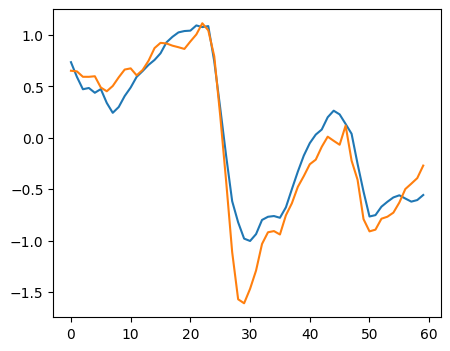

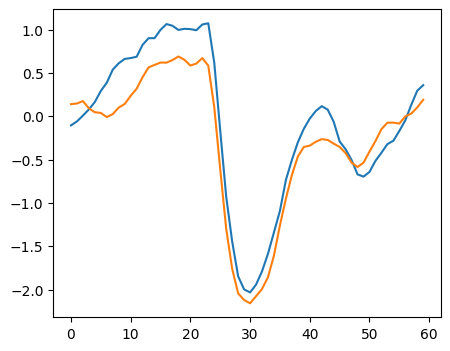

In [88]:
# plot pupil in early and late
ctl_animals = [0,4,7,8]
tst_animals = [1,8,10]
ctl_animals = [7]
tst_animals = [10]
grat = 'gr_1'
for ani in ctl_animals+tst_animals:
    if ani in ctl_animals:
        gr = data_ctl[ani]['grating_indices'][grat]
        fig,axes = plt.subplots(1,1,figsize=(5,4))
        pupil = data_ctl[ani]['pupil_rel'][gr]
        plt.plot(pupil[0:30,].mean(0))
        plt.plot(pupil[130:160,].mean(0))    
    else:
        gr = data_tst[ani]['grating_indices'][grat]
        fig,axes = plt.subplots(1,1,figsize=(5,4))
        pupil = data_tst[ani]['pupil_rel'][gr]
        plt.plot(pupil[:30,].mean(0))
        plt.plot(pupil[130:160,].mean(0))  

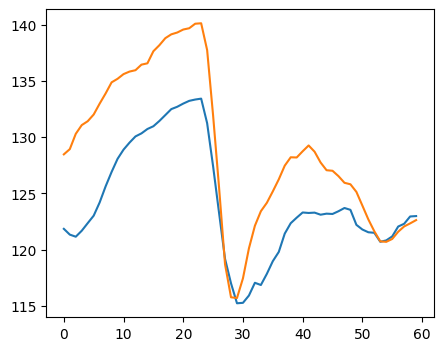

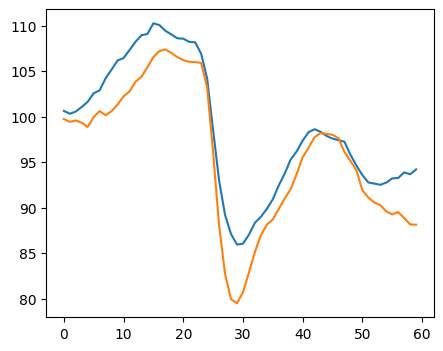

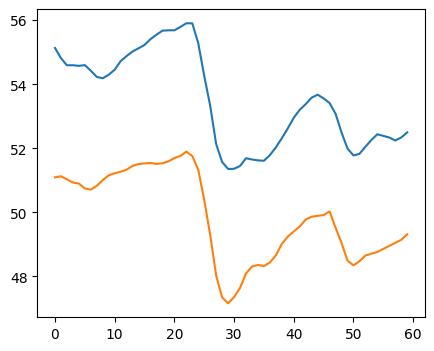

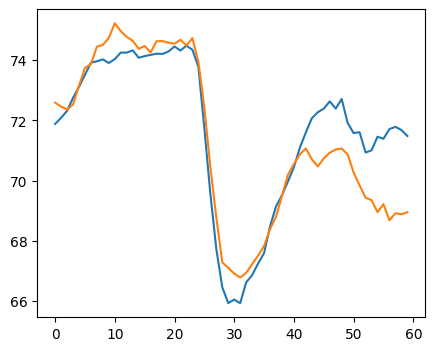

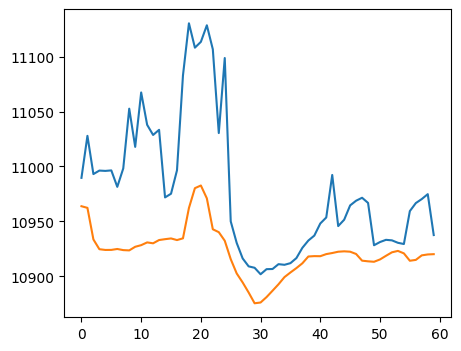

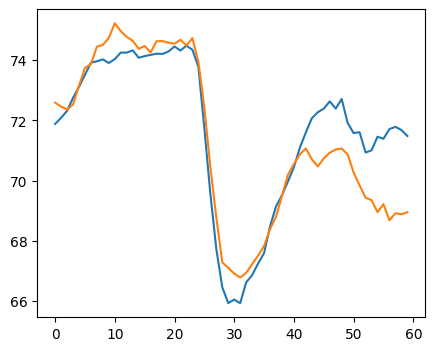

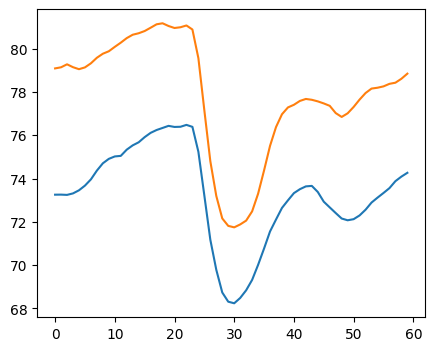

In [92]:
# plot pupil in early and late
ctl_animals = [0,4,7,8]
tst_animals = [1,8,10]
# ctl_animals = [7]
# tst_animals = [10]
grat = 'gr_1'
for ani in ctl_animals+tst_animals:
    if ani in ctl_animals:
        gr = data_ctl[ani]['grating_indices'][grat]
        fig,axes = plt.subplots(1,1,figsize=(5,4))
        pupil = data_ctl[ani]['pupil'][gr]
        plt.plot(pupil[0:60,].mean(0))
        plt.plot(pupil[100:160,].mean(0))    
    else:
        gr = data_tst[ani]['grating_indices'][grat]
        fig,axes = plt.subplots(1,1,figsize=(5,4))
        pupil = data_tst[ani]['pupil'][gr]
        plt.plot(pupil[:60,].mean(0))
        plt.plot(pupil[100:160,].mean(0))  

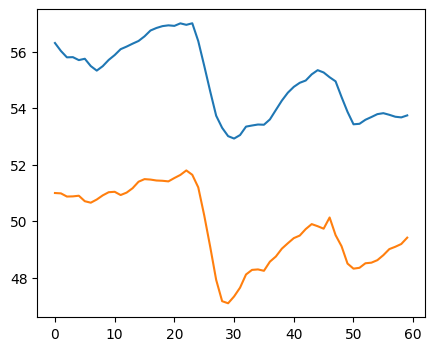

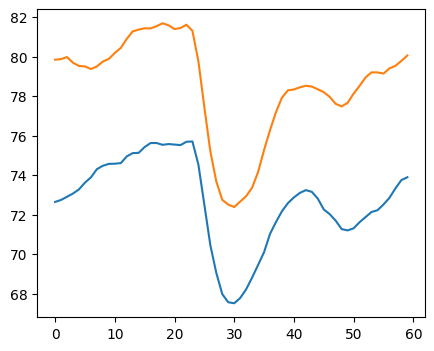

In [72]:
# plot pupil in early and late
ctl_animals = [0,4,7,8]
tst_animals = [1,8,10]
ctl_animals = [7]
tst_animals = [10]
grat = 'gr_1'
for ani in ctl_animals+tst_animals:
    if ani in ctl_animals:
        gr = data_ctl[ani]['grating_indices'][grat]
        fig,axes = plt.subplots(1,1,figsize=(5,4))
        pupil = data_ctl[ani]['pupil'][gr]
        plt.plot(pupil[0:30,].mean(0))
        plt.plot(pupil[130:160,].mean(0))    
    else:
        gr = data_tst[ani]['grating_indices'][grat]
        fig,axes = plt.subplots(1,1,figsize=(5,4))
        pupil = data_tst[ani]['pupil'][gr]
        plt.plot(pupil[:30,].mean(0))
        plt.plot(pupil[130:160,].mean(0))  

pupil plots: w and w/o bootstrapping
around grating
around reward

remove any mice that show weird pupil dynamics

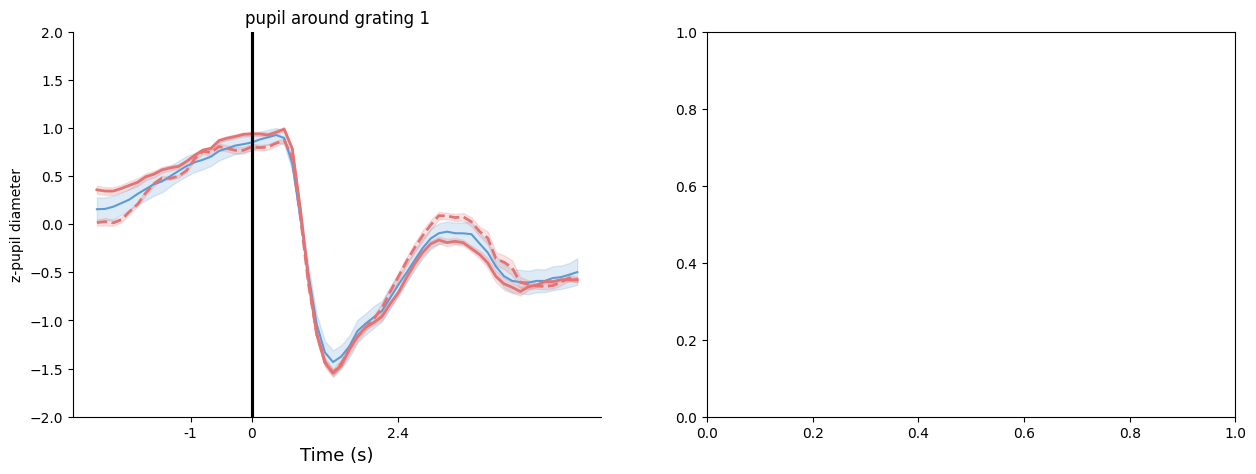

In [23]:
# control near gratings --- bootstrap
fig,axes = plt.subplots(1,2,figsize = (15,5))
af_b.bootstrap(data_ctl, animals = ctl_animals,  axes = axes[0], all_axes = axes, behv = 'pupil', stim_type = 'grat_1', n_boot=1000, early_tri=slice(0,40),late_tri=slice(6,15))
# af_b.bootstrap(data_ctl, animals = ctl_animals,  axes = axes[1], all_axes = axes, behv = 'pupil', stim_type = 'grat_2', n_boot=1000, early_tri=slice(0,4),late_tri=slice(6,15))

TypeError: object of type 'numpy.float64' has no len()

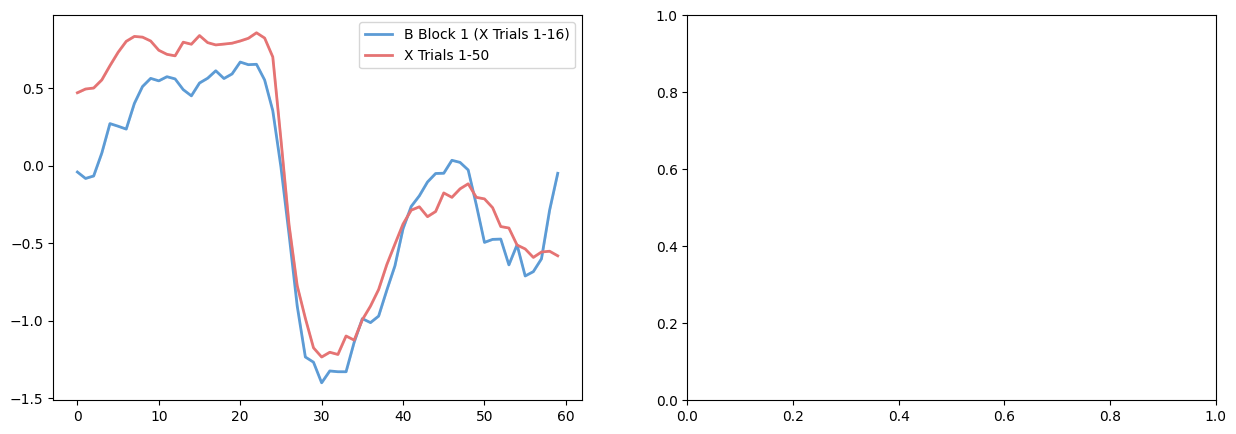

In [17]:
# control near gratings --- avg
fig,axes = plt.subplots(1,2,figsize = (15,5))
af_b.avg_plot(data_ctl, animals = [8],  axes = axes[0], all_axes = axes, behv = 'pupil', stim_type = 'grat_1', early_tri=slice(0,50),late_tri=slice(100,150))
# af_b.avg_plot(data_ctl, animals = ctl_animals,  axes = axes[1], all_axes = axes, behv = 'pupil', stim_type = 'grat_2', early_tri=slice(0,4),late_tri=slice(6,15))

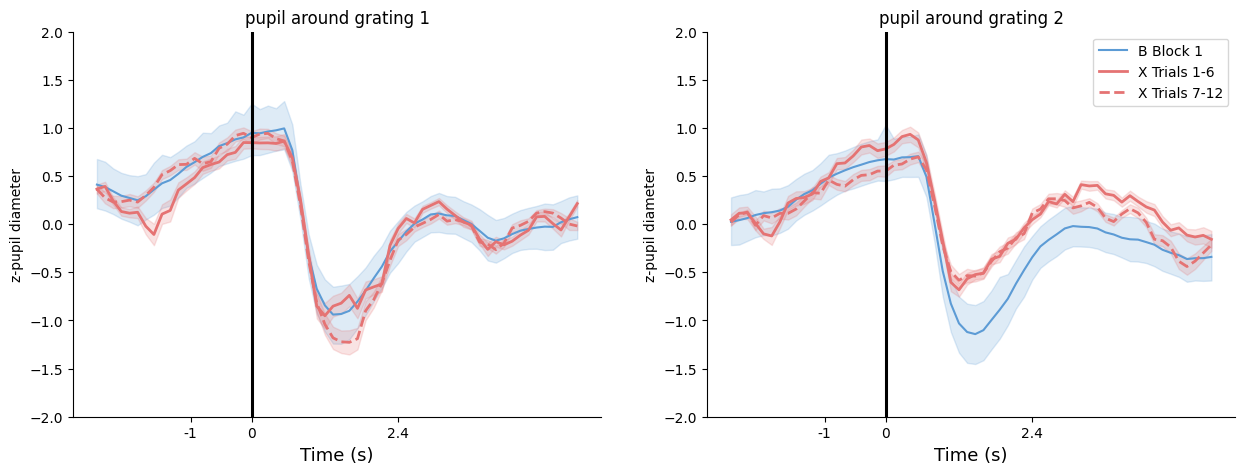

In [ ]:
# test near gratings --- bootstrap
fig,axes = plt.subplots(1,2,figsize = (15,5))
af_b.bootstrap(data_tst, animals = [1,2,3,6,10,11,12],  axes = axes[0], all_axes = axes, behv = 'pupil', stim_type = 'grat_1', n_boot=1000, early_tri=slice(0,6),late_tri=slice(6,12))
af_b.bootstrap(data_tst, animals = [1,2,3,6,10,11,12],  axes = axes[1], all_axes = axes, behv = 'pupil', stim_type = 'grat_2', n_boot=1000, early_tri=slice(0,6),late_tri=slice(6,12))

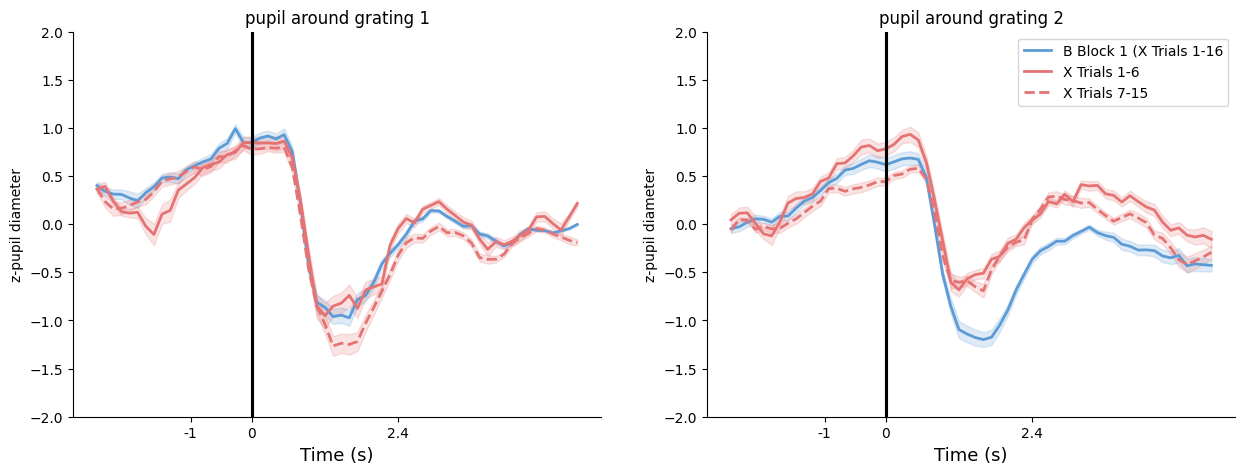

In [ ]:
# test near gratings --- avg
fig,axes = plt.subplots(1,2,figsize = (15,5))
af_b.avg_plot(data_tst, animals = [1,2,3,6,10,11,12],  axes = axes[0], all_axes = axes, behv = 'pupil', stim_type = 'grat_1', early_tri=slice(0,6),late_tri=slice(6,15))
af_b.avg_plot(data_tst, animals = [1,2,3,6,10,11,12],  axes = axes[1], all_axes = axes, behv = 'pupil', stim_type = 'grat_2', early_tri=slice(0,6),late_tri=slice(6,15))

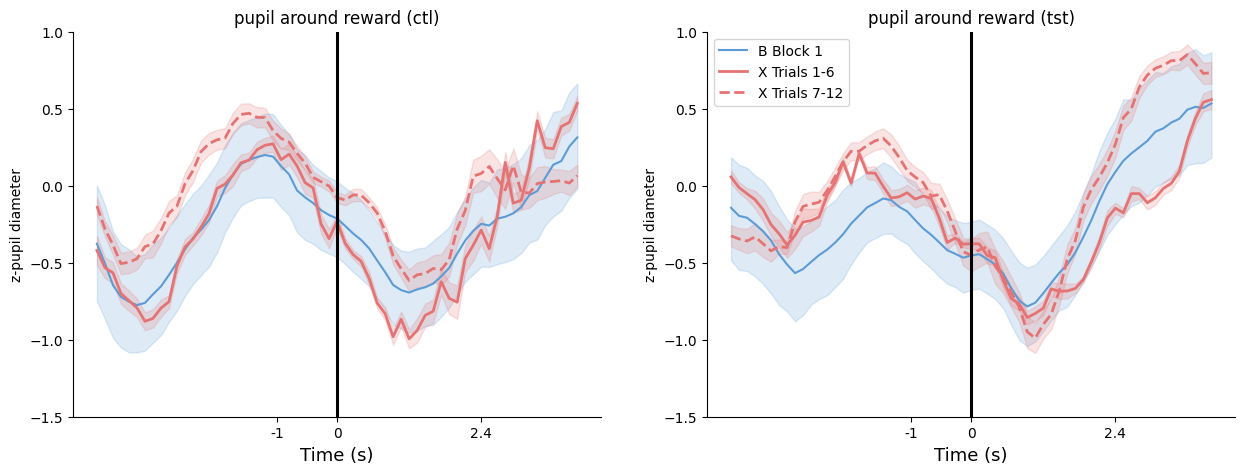

In [472]:
# control & test near reward --- bootstrap
fig,axes = plt.subplots(1,2,figsize = (15,5))
af_b.bootstrap(data_ctl, animals = ctl_animals,  axes = axes[0], all_axes = axes, behv = 'pupil', stim_type = 'rw', n_boot=10000, early_tri=slice(0,6),late_tri=slice(6,12))
af_b.bootstrap(data_tst, animals = [1,5,8,9,10],  axes = axes[1], all_axes = axes, behv = 'pupil', stim_type = 'rw', n_boot=10000, early_tri=slice(0,6),late_tri=slice(6,12))

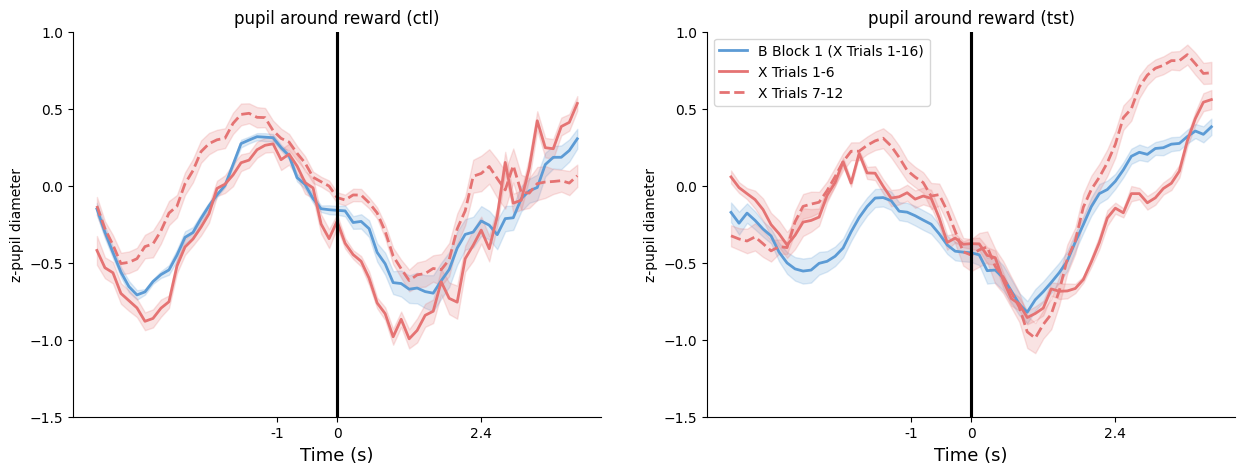

In [ ]:
# control & test near reward --- bootstrap
fig,axes = plt.subplots(1,2,figsize = (15,5))
af_b.avg_plot(data_ctl, animals = ctl_animals,  axes = axes[0], all_axes = axes, behv = 'pupil', stim_type = 'rw', early_tri=slice(0,6),late_tri=slice(6,12))
af_b.avg_plot(data_tst, animals = [1,5,8,9,10],  axes = axes[1], all_axes = axes, behv = 'pupil', stim_type = 'rw', early_tri=slice(0,6),late_tri=slice(6,12))

In [ ]:
ctl_animals = [0,4,7,8]
tst_animals = [1,2,3,4,5,6,7,8,9,10,11,12]

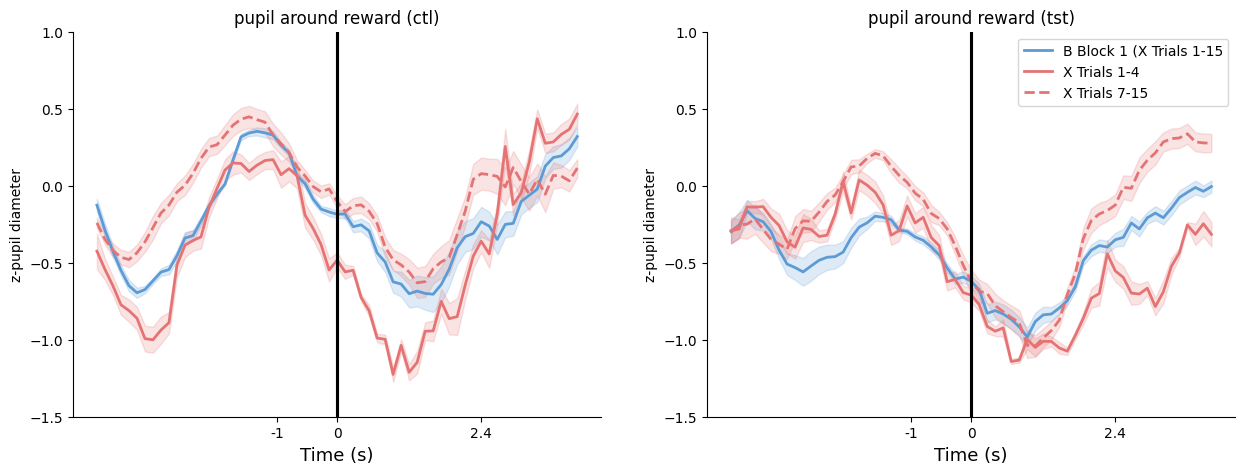

In [14]:
fig,axes = plt.subplots(1,2,figsize = (15,5))
af_b.avg_plot(data_ctl, animals = ctl_animals,  axes = axes[0], all_axes = axes, behv = 'pupil', stim_type = 'rw', early_tri=slice(0,4),late_tri=slice(6,15), exp_tri=slice(0,15))
af_b.avg_plot(data_tst, animals = tst_animals,  axes = axes[1], all_axes = axes, behv = 'pupil', stim_type = 'rw', early_tri=slice(0,4),late_tri=slice(6,15), exp_tri=slice(0,15))

---------------------

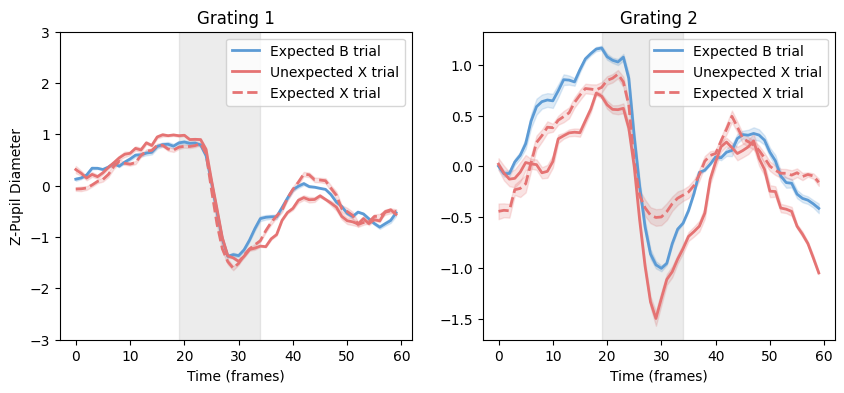

In [ ]:
# Pupil Size Averaged (Ctl)

fig,axes = plt.subplots(1,2,figsize=(10,4))
unexp_grat = {}
exp_grat = {}
for ani in data_ctl:
    unexp_grat[ani] = []
    exp_grat[ani] = []
    for trial in data_ctl[ani]['unpred_trials']['gr_2']:
        unexp_grat[ani].append(data_ctl[ani]['grating_indices']['gr_1'][trial])
    for trial in data_ctl[ani]['unpred_trials']['gr_2']:
        exp_grat[ani].append(data_ctl[ani]['grating_indices']['gr_1'][trial-1])
t_frames = 60
af.plot_shaded_error(axes[0], range(t_frames), np.mean(np.stack([data_ctl[ani]['pupil'][exp_grat[ani][6:12]] for ani in ctl_animals]), axis = 1),color='#5C9BD5', alpha=0.2,  label= 'Expected B trial')
af.plot_shaded_error(axes[0], range(t_frames), np.mean(np.stack([data_ctl[ani]['pupil'][unexp_grat[ani][:6]] for ani in ctl_animals]), axis = 1) ,color='#E57373', alpha=0.2,label = 'Unexpected X trial')
af.plot_shaded_error(axes[0], range(t_frames), np.mean(np.stack([data_ctl[ani]['pupil'][unexp_grat[ani][6:12]] for ani in ctl_animals]), axis = 1),color='#E57373', alpha=0.2,label= 'Expected X trial', style = 'dash')
axes[0].set_title('Grating 1')
axes[0].axvspan(19, 34, color='gray', alpha=0.15)
axes[0].set_xlabel('Time (frames)')
axes[0].set_ylim([-3,3])
axes[0].set_ylabel('Z-Pupil Diameter')
axes[0].legend()

unexp_grat = {}
exp_grat = {}
for ani in data_ctl:
    unexp_grat[ani] = []
    exp_grat[ani] = []
    for trial in data_ctl[ani]['unpred_trials']['gr_2']:
        unexp_grat[ani].append(data_ctl[ani]['grating_indices']['gr_2'][trial])
    for trial in data_ctl[ani]['unpred_trials']['gr_2']:
        exp_grat[ani].append(data_ctl[ani]['grating_indices']['gr_2'][trial-1])
t_frames = 60
af.plot_shaded_error(axes[1], range(t_frames), np.mean(np.stack([data_ctl[ani]['pupil'][exp_grat[ani][6:12]] for ani in ctl_animals]), axis = 1),color='#5C9BD5', alpha=0.2, label= 'Expected B trial')
af.plot_shaded_error(axes[1], range(t_frames), np.mean(np.stack([data_ctl[ani]['pupil'][unexp_grat[ani][:6]] for ani in ctl_animals]), axis = 1) ,color='#E57373', alpha=0.2,label = 'Unexpected X trial')
af.plot_shaded_error(axes[1], range(t_frames), np.mean(np.stack([data_ctl[ani]['pupil'][unexp_grat[ani][6:12]] for ani in ctl_animals]), axis = 1),color='#E57373', alpha=0.2,label= 'Expected X trial', style = 'dash')
axes[1].set_title('Grating 2')
axes[1].set_xlabel('Time (frames)')
axes[1].axvspan(19, 34, color='gray', alpha=0.15)
axes[1].set_ylabel('Z-Pupil Diameter')
axes[1].legend()